In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
import scipy.stats as stats

import os
import numpy as np
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from quad_model import *
from tensorflow.keras.models import Model, load_model
from  tqdm import tqdm

import mukund_utils as utils

random.seed(100)
np.random.seed(100)


In [2]:
model_keras = load_model('custom_adjacency_regularizer_20210731_124_step3.h5')
pre_tuner_model = Model(inputs=model_keras.inputs, outputs=model_keras.get_layer("energy_seq_struct").output)

In [3]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

In [4]:
def sigmoid_tuner(activation):
    return (sigmoid(np.array(model_keras.get_layer("gen_func")(np.array([[activation] ]))).flatten()))

In [5]:
rosenberg_et_al_data = pd.read_excel("rosenberg_et_al_supplementary_no_comments.xls")

In [6]:
SMN2_WT = "GGTTTTAGACAAAATCAAAAAGAAGGAAGGTGCTCACATTCCTTAAATTAAGGA"

def get_sequence(pos, seq):
    return SMN2_WT[:pos-1] + seq[:min(len(seq),len(SMN2_WT)-pos+1)] + SMN2_WT[min(pos+len(seq)-1, len(SMN2_WT)):]

def get_mutant_sequence_for_row(row):
    assert(get_sequence(row.POS, row.REF) == SMN2_WT)
    return(get_sequence(row.POS, row.ALT))

smn2_data = rosenberg_et_al_data[rosenberg_et_al_data.Gene == "SMN1/2"]
smn2_data = smn2_data[smn2_data.apply(lambda x: len(x.REF) == len(x.ALT), axis=1)] # ignore indels
smn2_data = smn2_data[smn2_data.REF_PSI < 0.5]  # take only SMN2, identified by its low REF_PSI; ignore SMN1
smn2_data = smn2_data[smn2_data.apply (lambda x : SMN2_WT[:3] == get_mutant_sequence_for_row(x)[:3], axis=1)] # first and last 3nt are the same (same filtering done in the Rosenberg notebook "genomic_predictions - Copy")
smn2_data = smn2_data[smn2_data.apply (lambda x : SMN2_WT[-3:] == get_mutant_sequence_for_row(x)[-3:], axis=1)]
smn2_data["sequence"] = smn2_data.apply(lambda x: utils.add_flanking("CCAAACAA"+get_mutant_sequence_for_row(x)+"CCAAACAA",10), axis=1)

In [7]:
smn2_data["pre_tuner_predictions"] = pre_tuner_model(utils.create_input_data(list(smn2_data.sequence))[:-1]).numpy().flatten()

shift = 0.5
0.22755339901249305


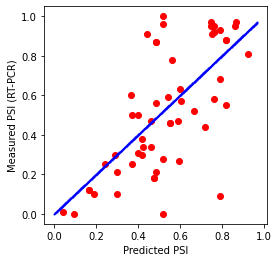

In [8]:
filtered_data = smn2_data

for scaling in [1]:#(1/3,1/2,3/4,1,4/3,3/2,2,3,4):
    # find the best shift so the wild type PSI matches the predicted PSI
    all_shifts = np.arange(-5,5,0.5)
    best_shift_index = np.argmin(np.linalg.norm(np.array(filtered_data["ALT_PSI"]).reshape(-1,1) - np.vectorize(sigmoid_tuner)((np.array(filtered_data.pre_tuner_predictions*scaling).reshape(-1,1) + all_shifts.reshape(1,-1)))
                                , axis=0))
    shift = all_shifts[best_shift_index]
    print(f"shift = {shift}")

    num_bins = 50
    x = filtered_data["ALT_PSI"]
    y = np.vectorize(sigmoid_tuner)(filtered_data.pre_tuner_predictions*scaling+shift)
    print(np.sqrt(((x-y)**2).mean()))
    #plt.hist2d(x,y,range=[[0,1.0],[0,1]], bins=[num_bins,num_bins], cmap='Blues', norm=matplotlib.colors.LogNorm(vmin=0.6))
    
    fig, ax = plt.subplots(1,1, figsize=(4,4))

    ax.scatter(y,x, c='r')
    ax.set_xlabel("Predicted PSI")
    ax.set_ylabel("Measured PSI (RT-PCR)")
    #plt.colorbar()

    reg = stats.linregress(x , y)

    left,right = plt.xlim()
    grid = np.linspace(left,right,500)
    #plt.scatter(grid, reg.intercept + grid * reg.slope, s=1, c='r')
    ax.scatter(grid, grid, s=1, c='b')

    #ax.set_title(f"SMN2 scaling = {scaling:.2f}, slope = {reg.slope:.2f}, r = {reg.rvalue:.2f}, rmse = {np.sqrt(((x-y)**2).mean()):.2f}") # intercept = {reg.intercept:.2f}, 

    plt.show()

In [11]:
from joblib import dump

In [12]:
dump([(x, y)], 'rosenberg_et_al.pkl')

['rosenberg_et_al.pkl']